# 2.5 Tokenizing Text


Fundamental step in NLP involves converting our text into smaller units through a process known as tokenization. These smaller units are known as our ## tokens. Word tokenization is the most common form of tokenization, where individual words in the text becomes a token, but tokens can also be sentences, sub words or individual characters depending on your use case.

Why do we do this? The meaning of the overall text is better understood if we can analyse and understand the individual parts as well as the whole. ## ## It's also an important step before we vecotrize our data, which we'll cover more in the next section of this course.

Now let's look at some examples of sentence and word tokenization using the nltk package.

In [4]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize, sent_tokenize

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Mike\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Sentance tokenization

In [5]:
sentences = "Her cat's name is Luna. Her dog's name is max"
sent_tokenize(sentences)

["Her cat's name is Luna.", "Her dog's name is max"]

## Word tokenization

In [6]:
sentence = "Her cat's name is Luna"
word_tokenize(sentence)

['Her', 'cat', "'s", 'name', 'is', 'Luna']

Notice how "cat's" has been split into 2 tokens. This may be fine for your task but it is definitely something to keep in mind when you are preprocessing any text data - you might want to remove punctuation or replace contractions before tokenizing.

In [7]:
sentence_2 = "Her cat's name is Luna and her dog's name is max"
word_tokenize(sentence_2)

['Her',
 'cat',
 "'s",
 'name',
 'is',
 'Luna',
 'and',
 'her',
 'dog',
 "'s",
 'name',
 'is',
 'max']

# 2.6 Stemming
The next step in preprocessing is to standardise the text. One option for this is stemming, 
where words are reduced to their base form. For example, words like ‘connecting’ or ‘connected’ 
will be stemmed to the base form ‘connect’. Stemming works by removing suffix/ending of word 
but can sometimes lead to the base form not being meaningful or a proper word.

We standardize the text in this way because it will lower the number of unique words in our dataset; 
therefore reducing the size and complexity of our data. Removing complexity and noise from the data
is an important step for preparing our data properly for machine learning.

In [11]:
from nltk.stem import PorterStemmer

In [12]:
# create stemmer
ps = PorterStemmer()

In [13]:
connect_tokens = ['connecting', 'connected', 'connectivity', 'connect', 'connects']

In [14]:
for t in connect_tokens:
    print(t, " : ", ps.stem(t))

connecting  :  connect
connected  :  connect
connectivity  :  connect
connect  :  connect
connects  :  connect


In [15]:
learn_tokens = ['learned', 'learning', 'learn', 'learns', 'learner', 'learners']

In [16]:
for t in learn_tokens:
    print(t, " : ", ps.stem(t))

learned  :  learn
learning  :  learn
learn  :  learn
learns  :  learn
learner  :  learner
learners  :  learner


In [18]:
likes_tokens = ['likes', 'better', 'worse']

In [19]:
for t in likes_tokens:
    print(t, " : ", ps.stem(t))

likes  :  like
better  :  better
worse  :  wors


# 2.7 Lemmatization
Where stemming removes the last few characters of a word, lemmatization stems the word to a more meaningful base form and ensures it does not lose it's meaning. Lemmatization works more intelligently, referencing a pre-defined dictionary containing the context of words and uses this when diminishing the word to the base form.

In [29]:
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Mike\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [31]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()


In [32]:
for t in connect_tokens:
    print(t, " : ", lemmatizer.lemmatize(t))

connecting  :  connecting
connected  :  connected
connectivity  :  connectivity
connect  :  connect
connects  :  connects


In [33]:
for t in learn_tokens:
    print(t, " : ", lemmatizer.lemmatize(t))

learned  :  learned
learning  :  learning
learn  :  learn
learns  :  learns
learner  :  learner
learners  :  learner


In [34]:
for t in likes_tokens:
    print(t, " : ", lemmatizer.lemmatize(t))

likes  :  like
better  :  better
worse  :  worse


# 2.8 N-grams
We can break our text down into n-grams to check our preprocessing, explore the contents of our
data, or create new features for machine learning. An n-gram is simply a sequence of neighbouring
n words (or tokens), where n can be any number.

In [35]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
tokens = ['the', 'rise', 'of', 'artificial', 'intelligence', 'has', 'led', 'to', 'significant', 
          'advancements', 'in', 'natural', 'language', 'processing', 'computer', 'vision', 'and',
          'other', 'fields', 'machine', 'learning', 'algorithms', 'are', 'becoming', 'more',
          'sophisticated', 'enabling', 'computers', 'to', 'perform', 'complex', 'tasks', 'that',
          'were', 'once', 'thought', 'to', 'be', 'the', 'exclusive', 'domain', 'of', 'humans',
          'with', 'the', 'advent', 'of', 'deep', 'learning', 'neural', 'networks', 'have',
          'become', 'even', 'more', 'powerful', 'capable', 'of', 'processing', 'vast',
          'amounts', 'of', 'data', 'and', 'learning', 'from', 'it', 'in', 'ways', 'that',
          'were', 'not', 'possible', 'before', 'as', 'a', 'result', 'ai', 'is', 'increasingly',
          'being', 'used', 'in', 'a', 'wide', 'range', 'of', 'industries', 'from', 'healthcare',
          'to', 'finance', 'to', 'transportation', 'and', 'its', 'impact', 'is', 'only', 'set',
          'to', 'grow', 'in', 'the', 'years', 'to', 'come']
print(tokens)

['the', 'rise', 'of', 'artificial', 'intelligence', 'has', 'led', 'to', 'significant', 'advancements', 'in', 'natural', 'language', 'processing', 'computer', 'vision', 'and', 'other', 'fields', 'machine', 'learning', 'algorithms', 'are', 'becoming', 'more', 'sophisticated', 'enabling', 'computers', 'to', 'perform', 'complex', 'tasks', 'that', 'were', 'once', 'thought', 'to', 'be', 'the', 'exclusive', 'domain', 'of', 'humans', 'with', 'the', 'advent', 'of', 'deep', 'learning', 'neural', 'networks', 'have', 'become', 'even', 'more', 'powerful', 'capable', 'of', 'processing', 'vast', 'amounts', 'of', 'data', 'and', 'learning', 'from', 'it', 'in', 'ways', 'that', 'were', 'not', 'possible', 'before', 'as', 'a', 'result', 'ai', 'is', 'increasingly', 'being', 'used', 'in', 'a', 'wide', 'range', 'of', 'industries', 'from', 'healthcare', 'to', 'finance', 'to', 'transportation', 'and', 'its', 'impact', 'is', 'only', 'set', 'to', 'grow', 'in', 'the', 'years', 'to', 'come']


In [38]:
# unigrams: n=1
unigrams = (pd.Series(nltk.ngrams(tokens, 1)).value_counts()) 
print(unigrams[:10])

(to,)          7
(of,)          6
(the,)         4
(in,)          4
(learning,)    3
(and,)         3
(from,)        2
(more,)        2
(is,)          2
(that,)        2
Name: count, dtype: int64


Text(0.5, 1.0, '10 Most requently Occuring Unigrams')

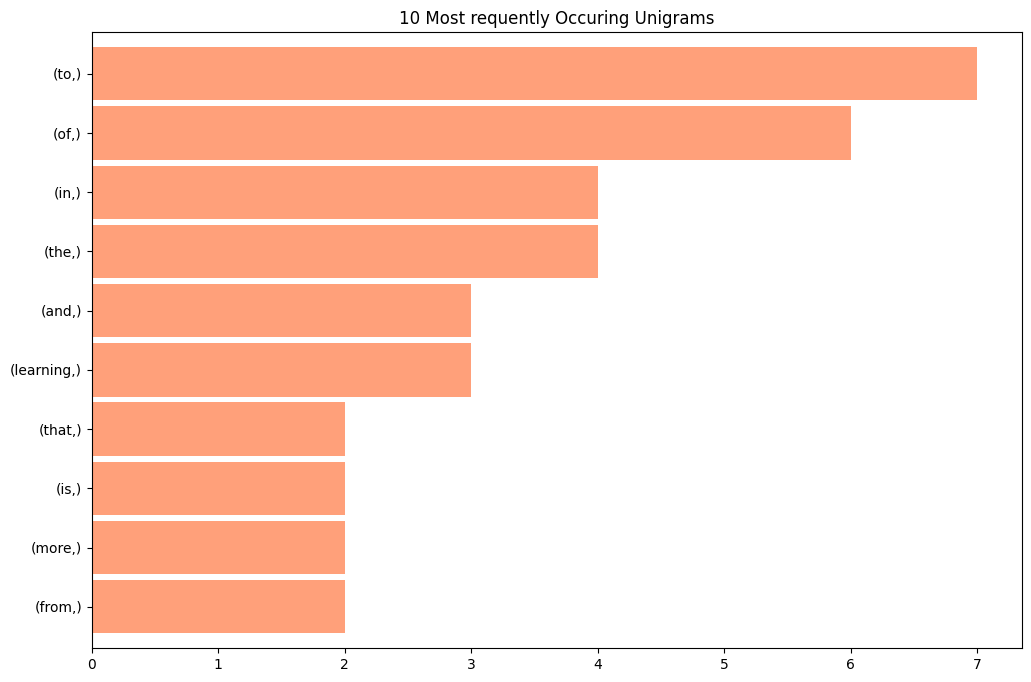

In [40]:
unigrams[:10].sort_values().plot.barh(color='lightsalmon', width=0.9, figsize=(12,8))
plt.title('10 Most requently Occuring Unigrams')

In [42]:
# bigrams: n=2
bigrams = (pd.Series(nltk.ngrams(tokens, 2)).value_counts()) 
print(bigrams[:10])

(that, were)             2
(the, rise)              1
(increasingly, being)    1
(ai, is)                 1
(result, ai)             1
(a, result)              1
(as, a)                  1
(before, as)             1
(possible, before)       1
(not, possible)          1
Name: count, dtype: int64


Text(0.5, 0, '# of Occurances')

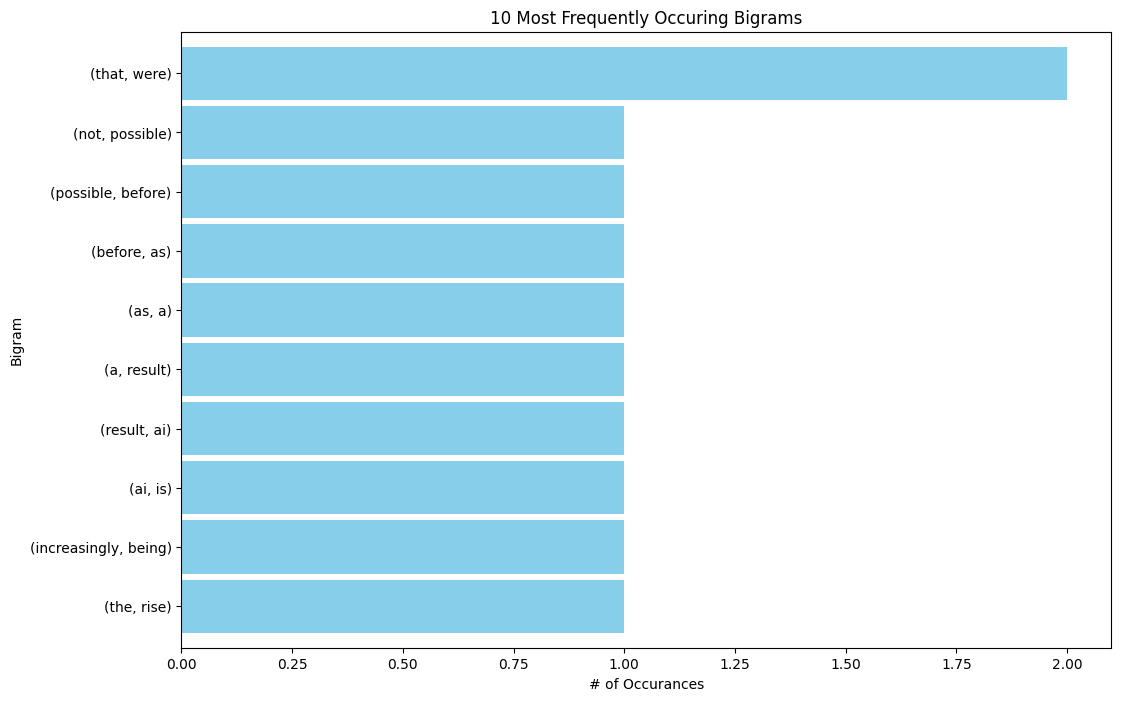

In [44]:
bigrams[0:10].sort_values().plot.barh(color='skyblue', width=.9, figsize=(12, 8))
plt.title('10 Most Frequently Occuring Bigrams')
plt.ylabel('Bigram')
plt.xlabel('# of Occurances')

In [43]:
# trigrams: n=3
trigrams = (pd.Series(nltk.ngrams(tokens, 3)).value_counts()) 
print(trigrams[:10])

(the, rise, of)            1
(even, more, powerful)     1
(ai, is, increasingly)     1
(result, ai, is)           1
(a, result, ai)            1
(as, a, result)            1
(before, as, a)            1
(possible, before, as)     1
(not, possible, before)    1
(were, not, possible)      1
Name: count, dtype: int64
